# Cars4You - Handout Project | Group 42
## Notebook 1 — Models Lab
**Course:** MSc in Data Science and Advanced Analytics, NOVA IMS (2025/2026)  

**Author(s):** Group 42
- `Miguel Matos - 20221925`
- `Andre Nicolau - 20221918`
- `André Ferreira - 20250398`


---

#### <font> Table of Contents </font> <a class="anchor" id='toc'></a> 
1. [Imports](#Imports)  
2. [Bayes Search](#bayes-search) 
- 2.1. [Random Forest](#random-forest)
- 2.2. [Extra Trees](#extra-trees)
- 2.3. [Hist Gradient Boosting](#hist-gradient-boosting)
----

# Imports
[Back to TOC](#toc)

In [69]:
from utils.functions import *
from utils.Nuestra_Pipeline import NuestraPipeline
from Preprocessing_pipelines.Outliers_pipeline import OutliersDealer
from Preprocessing_pipelines.Missing_Values_pipeline import MissingValuesDealer
from Preprocessing_pipelines.Encoding_pipeline import EncodingDealer
from Preprocessing_pipelines.Scaling_pipeline import ScalingDealer
from Preprocessing_pipelines.Feature_Selection_pipeline import FeatureSelectionDealer
import warnings

# Suppress this specific warning
warnings.filterwarnings('ignore', 
                       message='X does not have valid feature names',
                       category=UserWarning,
                       module='sklearn.utils.validation')

data = pd.read_csv("../data/data_cleaned.csv", index_col= "carID")
pd.set_option("display.max_columns", None)

In [70]:
data = data.sample(frac=1).reset_index(drop=True)

As the objective is to create a predictive model that is accurate without the need of the mechanic's assessment, we'll drop the "paintQuality%" column.

In [71]:
data.drop("paintQuality%", axis = 1, inplace= True)

In [72]:
X = data.drop("price", axis= 1)
y = data["price"]

# Bayes Search

In [73]:
RF_tuned = joblib.load('models/models_organized/models_tuning/rf_tuned.pkl')

ET_tuned_best = joblib.load('models/models_organized/models_tuning/et_tuned_best.pkl')

HGB_tuned_best = joblib.load('models/models_organized/models_tuning/hgb_tuned_best.pkl')

### Random Forest

In [74]:
RF_tuned

,imputer,MissingValues...thod='robust')
,outlier_remover,"OutliersDeale...'tax', 'mpg'])"
,encoder,EncodingDeale...thod='target')
,scaler,ScalingDealer()
,selector,FeatureSelect...ethod='model')
,model,RandomForestR...stimators=600)
,q,5
,method,'target'
,cols,None
,handle_unknown,'ignore'
,min_freq,0


In [79]:
rf = RandomForestRegressor()

parameters = {
              "model": [rf],
              "model__criterion" : ["squared_error", "poisson"], #absolute error will be left out due to it's high running time
              "model__n_estimators" : np.arange(400, 800, 10),
              "model__max_depth": np.arange(20, 50, 2),
              "model__max_features" : ['sqrt', 'log2', 0.5, 0.6, 0.7, 0.8, 0.9],
              "model__min_impurity_decrease" : [0.05, 0.1, 0.2],
              "model__min_samples_split" : np.arange(2, 50, 2),
              "model__max_samples" : [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
              "model__min_samples_leaf" : np.arange(2, 50, 2)
}

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

random_search = BayesSearchCV(RF_tuned, #already has the preprocessing for random forest
                                parameters, 
                                n_iter=100,  
                                scoring=mae_scorer,  
                                verbose=3, 
                                cv=5, 
                                n_jobs=5,
                                optimizer_kwargs = {
                                    'n_initial_points': 30,  # Increase from 10 to 40% of n_iter
                                    'acq_func': 'gp_hedge',  # Adaptively switches between EI, LCB, PI
                                    'acq_optimizer': 'sampling',
                                    'acq_func_kwargs': {
                                        'xi': 0.05,  # Increase exploration (default 0.01)
                                        'kappa': 5.0  # For LCB, higher = more exploration
                                        }
                                                    },
                                random_state=42  
                            )

In [80]:
random_search.fit(X, y)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 4/5] END model=RandomForestRegressor(), model__criterion=poisson, model__max_depth=46, model__max_features=0.5, model__max_samples=0.6, model__min_impurity_decrease=0.1, model__min_samples_leaf=18, model__min_samples_split=36, model__n_estimators=520;, score=-1670.481 total time=  43.0s
[CV 1/5] END model=RandomForestRegressor(), model__criterion=poisson, model__max_depth=46, model__max_features=0.5, model__max_samples=0.6, model__min_impurity_decrease=0.1, model__min_samples_leaf=18, model__min_samples_split=36, model__n_estimators=520;, score=-1681.757 total time=  43.1s
[CV 3/5] END model=RandomForestRegressor(), model__criterion=poisson, model__max_depth=46, model__max_features=0.5, model__max_samples=0.6, model__min_impurity_decrease=0.1, model__min_samples_leaf=18, model__min_samples_split=36, model__n_estimators=520;, score=-1667.276 total time=  43.2s
[CV 2/5] END model=RandomForestRegressor(), model__criterion=pois

,estimator,NuestraPipeli...thod='model'))
,search_spaces,"{'model': [RandomForestRegressor()], 'model__criterion': ['squared_error', 'poisson'], 'model__max_depth': array([20, 22..., 44, 46, 48]), 'model__max_features': ['sqrt', 'log2', ...], ...}"
,optimizer_kwargs,"{'acq_func': 'gp_hedge', 'acq_func_kwargs': {'kappa': 5.0, 'xi': 0.05}, 'acq_optimizer': 'sampling', 'n_initial_points': 30}"
,n_iter,100
,scoring,make_scorer(m...hod='predict')
,fit_params,None
,n_jobs,5
,n_points,1
,iid,'deprecated'
,refit,True
,cv,5


In [81]:
bayes_rf = pd.DataFrame(random_search.cv_results_)
#bayes_rf.to_csv("../data/final_data/Bayes_data/bayes_rf.csv")
#bayes_rf = pd.read_csv("../data/final_data/Bayes_data/bayes_rf.csv")

In [98]:
bayes_rf[["mean_fit_time", "mean_score_time", "mean_test_score", "std_test_score", "rank_test_score"]].sort_values(by="rank_test_score"
                                                                                                 , ascending= False).tail()

,mean_fit_time,mean_score_time,mean_test_score,std_test_score,rank_test_score
95,59.800538,2.348429,-1339.717806,11.645001,5
97,78.862245,3.627062,-1339.710800,10.691911,4
92,82.249130,3.970857,-1339.441191,10.639789,3
81,66.364789,2.590122,-1338.812598,11.189369,2
73,61.002283,2.396979,-1338.807817,11.162356,1


In [ ]:
# Storing the best model
#joblib.dump(random_search.best_estimator_, 'bayes_models/RF_bayes.pkl')
RF_tuned_best = joblib.load('bayes_models/RF_bayes.pkl')

['bayes_models/RF_bayes.pkl']

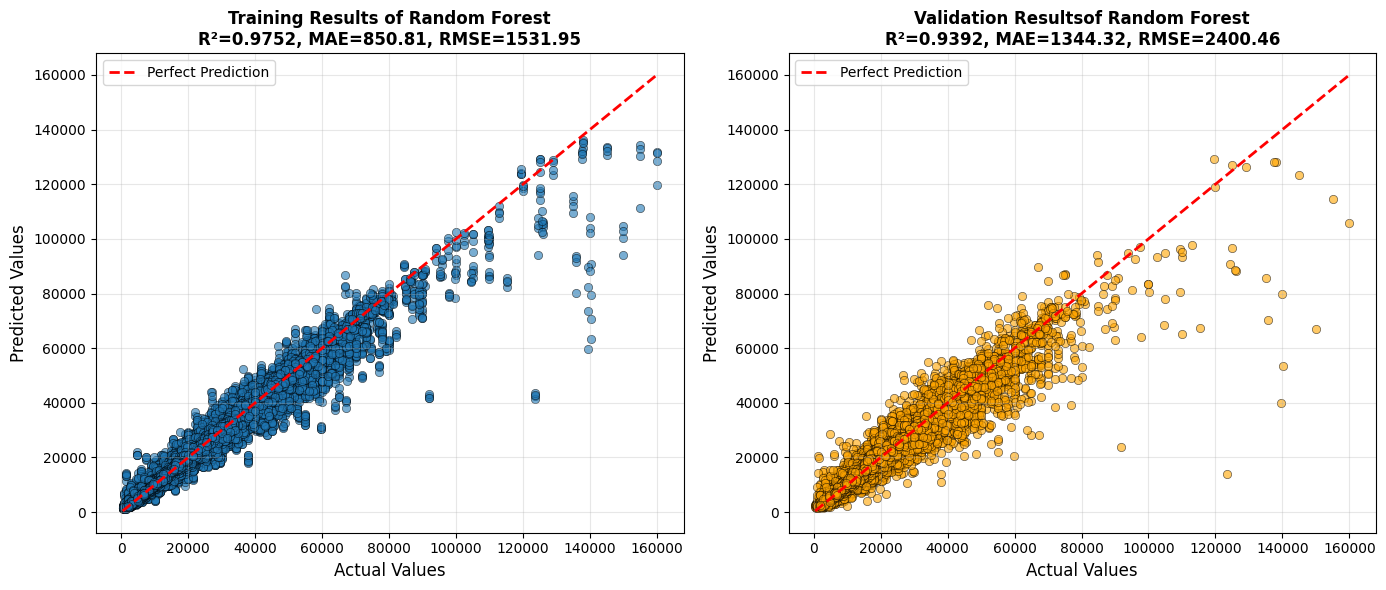

In [104]:
evaluate_best_model_with_cv(random_search.best_estimator_, X, y, model_name= "Random Forest", cv=5)

### Extra Trees

In [83]:
ET_tuned_best

,imputer,MissingValues...thod='robust')
,outlier_remover,"OutliersDeale...'tax', 'mpg'])"
,encoder,EncodingDeale...thod='target')
,scaler,ScalingDealer...me='standard')
,selector,FeatureSelect..._method='rfe')
,model,ExtraTreesReg...stimators=450)
,q,6
,method,'target'
,cols,None
,handle_unknown,'ignore'
,min_freq,0


In [84]:
et = ExtraTreesRegressor()

parameters = [{
              "model": [et],
              "model__criterion": ["squared_error"],
              "model__n_estimators": np.arange(250, 650, 10), 
              "model__max_depth": np.arange(60, 120, 5), # Depth: allow fully grown + several controlled-depth options
              "model__max_features": ["sqrt", "log2",0.6, 0.7, 0.8, 1.0], # Max features for ExtraTrees (random splits)
              "model__min_impurity_decrease": [0.0, 1e-4, 1e-3, 1e-2],  # Encourage pruning of bad splits
              "model__min_samples_split": np.arange(5, 65, 2),   # With your big dataset, larger splits help generalization    
              "model__min_samples_leaf": np.arange(3, 30, 3),   # Adds strong smoothing for regression
              "model__bootstrap": [True],   # ExtraTrees usually does NOT use bootstrap—but we let the search try it
              "model__max_samples": [0.5, 0.6, 0.7, 0.8, 0.9]   # If bootstrap=True, this is used. Otherwise it is ignored.    
    },

    {
        "model": [et],
              "model__criterion": ["squared_error"],
              "model__n_estimators": np.arange(250, 650, 10), # ExtraTrees is fast → you can afford many trees
              "model__max_depth": np.arange(60, 120, 5), # Depth: allow fully grown + several controlled-depth options
              "model__max_features": ["sqrt", "log2",0.6, 0.7, 0.8, 1.0], # Max features for ExtraTrees (random splits)
              "model__min_impurity_decrease": [0.0, 1e-4, 1e-3, 1e-2],  # Encourage pruning of bad splits
              "model__min_samples_split": np.arange(5, 65, 2),   # With your big dataset, larger splits help generalization    
              "model__min_samples_leaf": np.arange(3, 30, 3),   # Adds strong smoothing for regression
              "model__bootstrap": [False]

    }
]

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
ET_search = BayesSearchCV(ET_tuned_best, #already has the preprocessing for random forest
                                parameters, 
                                n_iter=70,  
                                scoring=mae_scorer,  
                                verbose=3, 
                                cv=5, 
                                n_jobs=5,
                                optimizer_kwargs = {
                                    'n_initial_points': 20,  # Increase from 10 to 40% of n_iter
                                    'acq_func': 'gp_hedge',  # Adaptively switches between EI, LCB, PI
                                    'acq_optimizer': 'sampling',
                                    'acq_func_kwargs': {
                                        'xi': 0.05,  # Increase exploration (default 0.01)
                                        'kappa': 5.0  # For LCB, higher = more exploration
                                        }
                                                    },
                                random_state=42  
                            )

In [85]:
ET_search.fit(X, y)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 2/5] END model=ExtraTreesRegressor(), model__bootstrap=True, model__criterion=squared_error, model__max_depth=115, model__max_features=1.0, model__max_samples=0.5, model__min_impurity_decrease=0.0, model__min_samples_leaf=12, model__min_samples_split=43, model__n_estimators=630;, score=-1707.771 total time=  28.4s
[CV 4/5] END model=ExtraTreesRegressor(), model__bootstrap=True, model__criterion=squared_error, model__max_depth=115, model__max_features=1.0, model__max_samples=0.5, model__min_impurity_decrease=0.0, model__min_samples_leaf=12, model__min_samples_split=43, model__n_estimators=630;, score=-1703.696 total time=  28.3s
[CV 1/5] END model=ExtraTreesRegressor(), model__bootstrap=True, model__criterion=squared_error, model__max_depth=115, model__max_features=1.0, model__max_samples=0.5, model__min_impurity_decrease=0.0, model__min_samples_leaf=12, model__min_samples_split=43, model__n_estimators=630;, score=-1698.659 

,estimator,NuestraPipeli...method='rfe'))
,search_spaces,"[{'model': [ExtraTreesRegressor()], 'model__bootstrap': [True], 'model__criterion': ['squared_error'], 'model__max_depth': array([ 60, ...05, 110, 115]), ...}, {'model': [ExtraTreesRegressor()], 'model__bootstrap': [False], 'model__criterion': ['squared_error'], 'model__max_depth': array([ 60, ...05, 110, 115]), ...}]"
,optimizer_kwargs,"{'acq_func': 'gp_hedge', 'acq_func_kwargs': {'kappa': 5.0, 'xi': 0.05}, 'acq_optimizer': 'sampling', 'n_initial_points': 20}"
,n_iter,70
,scoring,make_scorer(m...hod='predict')
,fit_params,None
,n_jobs,5
,n_points,1
,iid,'deprecated'
,refit,True
,cv,5


In [86]:
bayes_et = pd.DataFrame(ET_search.cv_results_)
#bayes_et.to_csv("../data/final_data/Bayes_data/bayes_et.csv")
#bayes_et = pd.read_csv("../data/final_data/Bayes_data/bayes_et.csv")

In [99]:
bayes_et[["mean_fit_time", "mean_score_time", "mean_test_score", "std_test_score", "rank_test_score"]].sort_values(by="rank_test_score"
                                                                                                 , ascending= False).tail()

,mean_fit_time,mean_score_time,mean_test_score,std_test_score,rank_test_score
136,43.019568,1.429182,-1351.186796,6.425497,5
126,44.417771,1.616635,-1351.111690,6.190634,4
119,52.136139,2.229956,-1350.917683,6.440941,3
131,51.042789,2.383621,-1350.565553,6.619328,2
139,38.544804,1.166873,-1350.466263,5.878863,1


In [ ]:
# Storing the best model
#joblib.dump(ET_search.best_estimator_, 'bayes_models/ET_bayes.pkl')
ET_tuned_best = joblib.load('bayes_models/ET_bayes.pkl')

['bayes_models/ET_bayes.pkl']

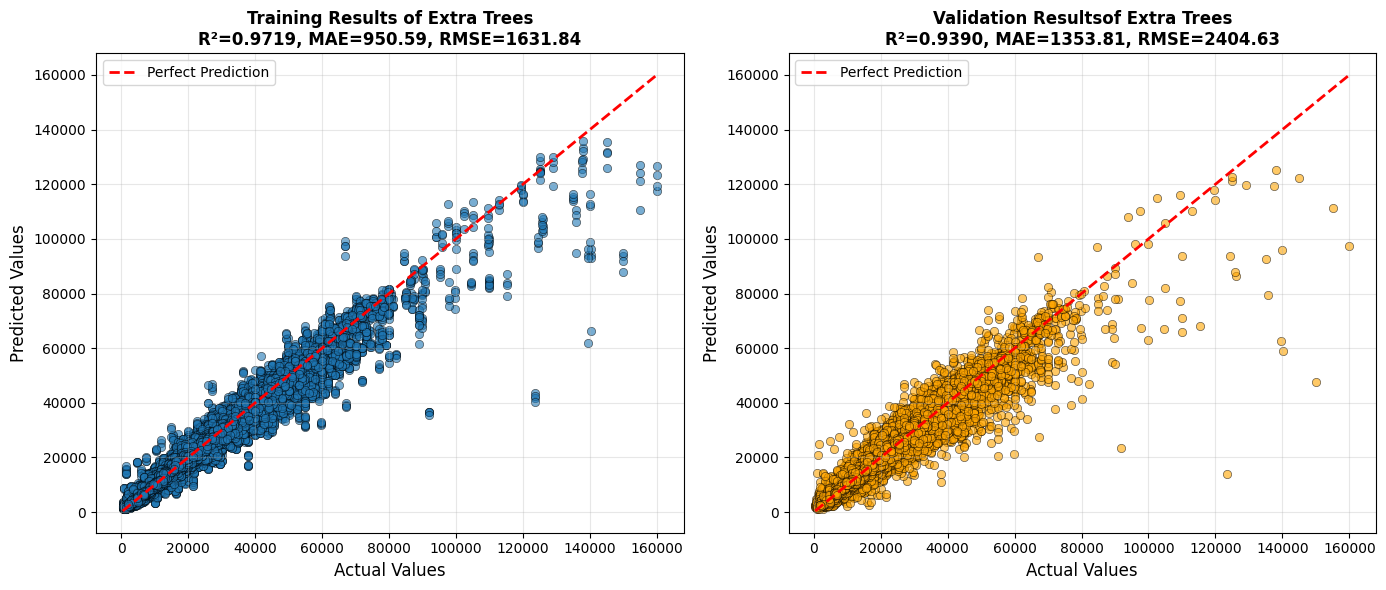

In [102]:
evaluate_best_model_with_cv(ET_search.best_estimator_, X, y,model_name= "Extra Trees", cv=5)

### Hist Gradient Boosting

In [88]:
HGB_tuned_best

,imputer,MissingValues...thod='robust')
,outlier_remover,"OutliersDeale...'tax', 'mpg'])"
,encoder,EncodingDeale...thod='target')
,scaler,ScalingDealer...me='standard')
,selector,FeatureSelect...ethod='kbest')
,model,HistGradientB...mples_leaf=35)
,q,11
,method,'target'
,cols,None
,handle_unknown,'ignore'
,min_freq,0


In [91]:
hgb = HistGradientBoostingRegressor()

parameters = parameters = {
    
            "model": [hgb],
            "model__max_iter": np.arange(50,350,20),              # Number of boosting iterations
            "model__max_depth": np.arange(15, 50, 2),              # Tree depth (None = unlimited)
            "model__learning_rate": [0.01, 0.05, 0.1, 0.2, 0.3, 0.4],      # Step size
            "model__min_samples_leaf": np.arange(15, 55, 3),        # Min samples in leaf
            "model__max_leaf_nodes": np.arange(40, 90, 4),         # Max leaves (2^k - 1 is typical)
            "model__l2_regularization": np.arange(1, 12, 2),   # L2 penalty
            "model__max_bins": np.arange(160, 255, 10), # Bins for histogram (255 is default)
            "model__max_features": [ 0.6, 0.7, 0.8, 0.9, 1.0],
            "q": np.arange(3,15,1)                      
}

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

HGB_search = BayesSearchCV(HGB_tuned_best, #already has the preprocessing for random forest
                                parameters, 
                                n_iter=150,  
                                scoring=mae_scorer,  
                                verbose=3, 
                                cv=5, 
                                n_jobs=5,
                                optimizer_kwargs = {
                                    'n_initial_points': 40,
                                    'acq_func': 'gp_hedge',  # Adaptively switches between EI, LCB, PI
                                    'acq_optimizer': 'sampling',
                                    'acq_func_kwargs': {
                                        'xi': 0.05,  # Increase exploration (default 0.01)
                                        'kappa': 5.0  # For LCB, higher = more exploration
                                        }
                                                    },
                                random_state=42  
                            )

In [92]:
HGB_search.fit(X, y)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 2/5] END model=HistGradientBoostingRegressor(), model__l2_regularization=9, model__learning_rate=0.4, model__max_bins=190, model__max_depth=39, model__max_features=0.8, model__max_iter=150, model__max_leaf_nodes=76, model__min_samples_leaf=27, q=10;, score=-1452.167 total time=   4.8s
[CV 1/5] END model=HistGradientBoostingRegressor(), model__l2_regularization=9, model__learning_rate=0.4, model__max_bins=190, model__max_depth=39, model__max_features=0.8, model__max_iter=150, model__max_leaf_nodes=76, model__min_samples_leaf=27, q=10;, score=-1455.656 total time=   4.9s
[CV 4/5] END model=HistGradientBoostingRegressor(), model__l2_regularization=9, model__learning_rate=0.4, model__max_bins=190, model__max_depth=39, model__max_features=0.8, model__max_iter=150, model__max_leaf_nodes=76, model__min_samples_leaf=27, q=10;, score=-1411.555 total time=   5.0s
[CV 5/5] END model=HistGradientBoostingRegressor(), model__l2_regulariz

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV 2/5] END model=HistGradientBoostingRegressor(), model__l2_regularization=11, model__learning_rate=0.01, model__max_bins=200, model__max_depth=21, model__max_features=0.8, model__max_iter=90, model__max_leaf_nodes=76, model__min_samples_leaf=36, q=14;, score=-3429.626 total time=   4.6s
[CV 3/5] END model=HistGradientBoostingRegressor(), model__l2_regularization=11, model__learning_rate=0.01, model__max_bins=200, model__max_depth=21, model__max_features=0.8, model__max_iter=90, model__max_leaf_nodes=76, model__min_samples_leaf=36, q=14;, score=-3458.791 total time=   4.7s
[CV 4/5] END model=HistGradientBoostingRegressor(), model__l2_regularization=11, model__learning_rate=0.01, model__max_bins=200, model__max_depth=21, model__max_features=0.8, model__max_iter=90, model__max_leaf_nodes=76, model__min_samples_leaf=36, q=14;, score=-3410.434 total time=   4.8s
[CV 1/5] END model=HistGradientBoostingRegressor(), model__l2_regularization=11, model__learning_rate=0.01, model__max_bins=200

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV 1/5] END model=HistGradientBoostingRegressor(), model__l2_regularization=9, model__learning_rate=0.4, model__max_bins=200, model__max_depth=27, model__max_features=0.7, model__max_iter=50, model__max_leaf_nodes=56, model__min_samples_leaf=39, q=5;, score=-1541.700 total time=   4.2s
[CV 2/5] END model=HistGradientBoostingRegressor(), model__l2_regularization=9, model__learning_rate=0.4, model__max_bins=200, model__max_depth=27, model__max_features=0.7, model__max_iter=50, model__max_leaf_nodes=56, model__min_samples_leaf=39, q=5;, score=-1558.966 total time=   4.2s
[CV 4/5] END model=HistGradientBoostingRegressor(), model__l2_regularization=9, model__learning_rate=0.4, model__max_bins=200, model__max_depth=27, model__max_features=0.7, model__max_iter=50, model__max_leaf_nodes=56, model__min_samples_leaf=39, q=5;, score=-1510.875 total time=   4.2s
[CV 3/5] END model=HistGradientBoostingRegressor(), model__l2_regularization=9, model__learning_rate=0.4, model__max_bins=200, model__ma

,estimator,NuestraPipeli...thod='kbest'))
,search_spaces,"{'model': [HistGradientB...ingRegressor()], 'model__l2_regularization': array([ 1, 3..., 7, 9, 11]), 'model__learning_rate': [0.01, 0.05, ...], 'model__max_bins': array([160, 1...30, 240, 250]), ...}"
,optimizer_kwargs,"{'acq_func': 'gp_hedge', 'acq_func_kwargs': {'kappa': 5.0, 'xi': 0.05}, 'acq_optimizer': 'sampling', 'n_initial_points': 40}"
,n_iter,150
,scoring,make_scorer(m...hod='predict')
,fit_params,None
,n_jobs,5
,n_points,1
,iid,'deprecated'
,refit,True
,cv,5


In [123]:
bayes_hgb = pd.DataFrame(HGB_search.cv_results_)
bayes_hgb.to_csv("../data/final_data/Bayes_data/bayes_hgb_2.csv")
bayes_hgb = pd.read_csv("../data/final_data/Bayes_data/bayes_hgb_2.csv")

In [124]:
bayes_hgb[["mean_fit_time", "mean_score_time", "mean_test_score", "std_test_score", "rank_test_score"]].sort_values(by="rank_test_score"
                                                                                                 , ascending= False).tail()

,mean_fit_time,mean_score_time,mean_test_score,std_test_score,rank_test_score
124,4.121495,0.891244,-1372.335109,16.920557,5
95,4.092110,0.796966,-1371.334225,17.294408,4
149,3.874581,0.731138,-1368.761475,25.186954,3
61,4.057543,0.824752,-1367.778237,15.736500,2
118,4.126183,0.786056,-1367.686257,19.089340,1


In [125]:
#joblib.dump(HGB_search.best_estimator_, "bayes_models/HGB_bayes.pkl")
HGB_tuned_best = joblib.load('bayes_models/HGB_bayes.pkl')

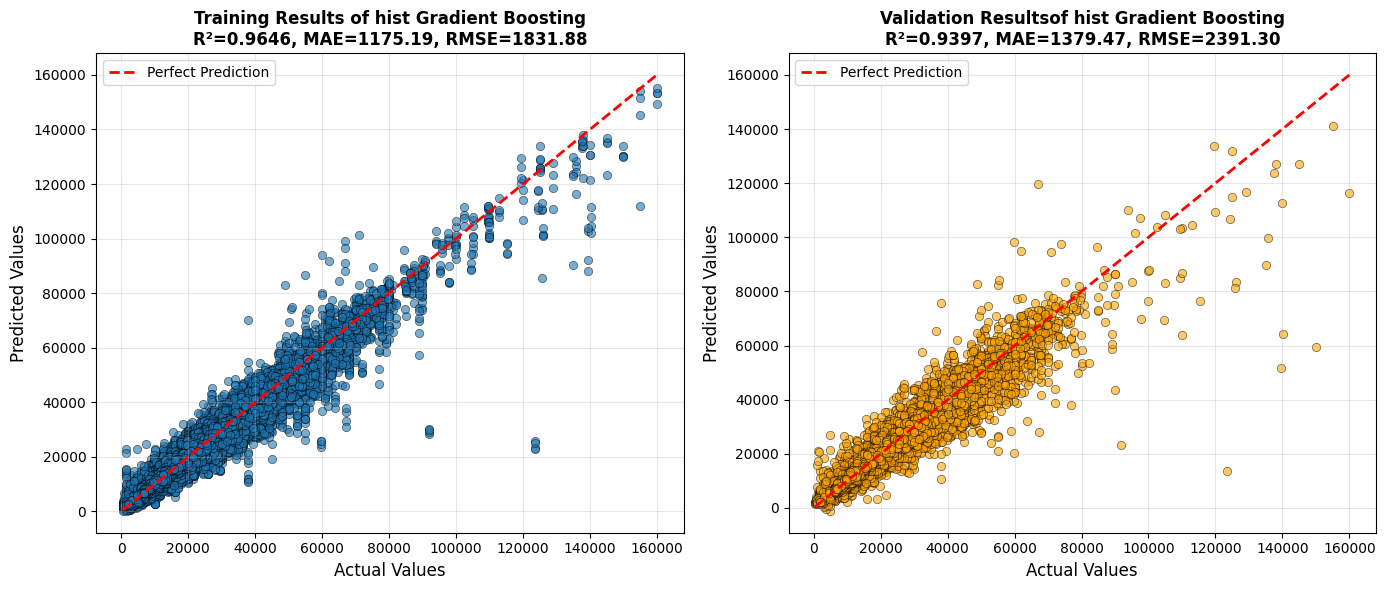

In [ ]:
evaluate_best_model_with_cv(HGB_search.best_estimator_, X, y,model_name= "Hist Gradient Boosting", cv=5)

# Delivery

In [113]:
X_test = pd.read_csv("../data/Test_clean.csv", index_col= "carID")
X_test.head()

,Brand,model,car_age,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners
carID,,,,,,,,,,
89856,Hyundai,I30,0.0,Automatic,30700.0,Petrol,205.0,41.5,1.6,3.0
106581,VW,Tiguan,3.0,Semi-Auto,NaN,Petrol,150.0,38.2,2.0,2.0
80886,BMW,6 series,4.0,Automatic,36792.0,Petrol,125.0,51.4,1.5,2.0
100174,Opel,Grandland x,1.0,Manual,5533.0,Petrol,145.0,44.1,1.2,1.0
81376,BMW,6 series,1.0,Semi-Auto,9058.0,Diesel,150.0,51.4,2.0,4.0


In [126]:
best_model = HGB_tuned_best

In [127]:
prediction = best_model.predict(X_test)

In [117]:
carID_test = X_test.index.values # Getting an array with the CarId ordered.

submission = pd.DataFrame({
    "price": prediction
}, index=carID_test) #A dataframe with the index as the CarID and the only column present beeing the predictions.

submission.index.name = "carID" #Naming the index as "carID"

In [118]:
submission

,price
carID,
89856,7280.304897
106581,23699.839052
80886,14579.480106
100174,17501.662104
81376,29077.421052
...,...
105775,17672.730679
81363,36048.913564
76833,33912.641458


In [119]:
submission.to_csv("../data/Submissions/HGB_model.csv")